# Only All-Rookie Teams CLF

## PCA

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

df = pd.read_csv("databases/nba_dataset_2010_2025.csv")

# Standaryzacja
X = df.drop(columns=["Player", "Team", "Pos", "season", "target", "potw", "potm"], errors="ignore")
X = X[X["is_rookie"] == 1].copy()
X.drop(columns=["is_rookie"], errors="ignore", inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

x_pca = PCA(n_components=20)
x_pca_transformed = x_pca.fit_transform(X_scaled)

# Udział wariancji
explained_variance = x_pca.explained_variance_ratio_
variance_df = pd.DataFrame({
    "Składowa": [f'PC{i+1}' for i in range(len(explained_variance))],
    "Wariancja [%]": explained_variance * 100
})
# Wyświetl wyniki
print("Wariancja wyjaśniona przez każdą składową PCA:")
print(variance_df)


Wariancja wyjaśniona przez każdą składową PCA:
   Składowa  Wariancja [%]
0       PC1      25.832192
1       PC2      10.439496
2       PC3       8.007334
3       PC4       7.108894
4       PC5       6.218980
5       PC6       3.453928
6       PC7       3.112339
7       PC8       2.528068
8       PC9       2.500204
9      PC10       2.321004
10     PC11       2.037565
11     PC12       1.937849
12     PC13       1.803057
13     PC14       1.670563
14     PC15       1.642578
15     PC16       1.532324
16     PC17       1.444905
17     PC18       1.391703
18     PC19       1.326086
19     PC20       1.150907


### Utworzenie DataFrame z 20 pierwszymi komponentami PCA

In [ ]:
# Utworzenie DataFrame z 20 pierwszymi komponentami PCA
pca_columns = [f'PC{i+1}' for i in range(20)]
X_pca_20 = pd.DataFrame(x_pca_transformed[:, :20], columns=pca_columns)

# Dołączenie kolumn meta
meta_cols = ["Player", "Team", "Pos", "season", "target"]
final_df = pd.concat([df[meta_cols].reset_index(drop=True), X_pca_20.reset_index(drop=True)], axis=1)

final_df.to_csv("databases/nba_dataset_2010_2025_pca20_rokkie.csv", index=False)

## XGB CLF - Rookie 

In [ ]:
import pandas as pd
import json
from xgboost import XGBClassifier

# === 1. Załaduj dane ===
df_full = pd.read_csv("databases/nba_dataset_2010_2025.csv")

# === 2. Przekształć target (4 → 1, 5 → 2, reszta → 0) ===
df_full["target"] = df_full["target"].apply(lambda x: 1 if x == 4 else (2 if x == 5 else 0))

# === 3. Filtruj tylko rookies ===
df_rookies = df_full[df_full["is_rookie"] == 1].copy()

X = df_rookies.drop(columns=["Player", "Team", "Pos", "season", "target"])
y = df_rookies["target"]

mask_train = df_rookies["season"] < 2025
mask_test = df_rookies["season"] == 2025

X_train = X[mask_train]
y_train = y[mask_train]
X_test = X[mask_test]
players_pred = df_rookies[mask_test]["Player"].reset_index(drop=True)

# === 4. Model ===
model = XGBClassifier(
    subsample=1.0,
    colsample_bytree=0.9,
    reg_lambda=5,
    reg_alpha=0,
    n_estimators=100,
    max_depth=5,
    learning_rate=0.01,
    gamma=1,
    eval_metric="mlogloss",
    random_state=42
)

model.fit(X_train, y_train)

# === 5. Predykcja ===
probas = model.predict_proba(X_test)
df_pred = pd.DataFrame(probas, columns=model.classes_)
df_pred["Player"] = players_pred

# === 6. Przygotowanie list zawodników rookie team ===
rookie_ranks = {
    "first rookie all-nba team": df_pred.sort_values(by=1, ascending=False)["Player"].tolist(),
    "second rookie all-nba team": df_pred.sort_values(by=2, ascending=False)["Player"].tolist()
}

results = {team: [] for team in rookie_ranks}
used_rookies = set()

while any(len(results[team]) < 5 for team in rookie_ranks):
    for team in ["first rookie all-nba team", "second rookie all-nba team"]:
        for player in rookie_ranks[team]:
            if player not in used_rookies:
                results[team].append(player)
                used_rookies.add(player)
                break

# === 8. Zapis JSON ===
output_path = "classification_rokkie_result_2025.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)



## XGB CLF Params Tuning - Rookie 

In [ ]:
import pandas as pd
import json
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score

# === 1. Załaduj dane ===
df_full = pd.read_csv("databases/nba_dataset_2010_2025.csv")

# === 2. Przekształć target (4 → 1, 5 → 2, reszta → 0) ===
df_full["target"] = df_full["target"].apply(lambda x: 1 if x == 4 else (2 if x == 5 else 0))

# === 3. Filtruj tylko rookies ===
df_rookies = df_full[df_full["is_rookie"] == 1].copy()

X = df_rookies.drop(columns=["Player", "Team", "Pos", "season", "target"])
y = df_rookies["target"]

mask_train = df_rookies["season"] < 2025
mask_test = df_rookies["season"] == 2025

X_train = X[mask_train]
y_train = y[mask_train]
X_test = X[mask_test]
players_pred = df_rookies[mask_test]["Player"].reset_index(drop=True)

# === 4. Randomized Search ===
param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
    "gamma": [0, 0.5, 1, 2],
    "reg_alpha": [0, 0.5, 1, 5],
    "reg_lambda": [0.1, 1, 5, 10]
}

base_model = XGBClassifier(random_state=42, eval_metric="mlogloss", use_label_encoder=False)

random_search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring=make_scorer(f1_score, average="macro"),
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)
model = random_search.best_estimator_

print("Najlepsze parametry:", random_search.best_params_)

# === 5. Predykcja ===
probas = model.predict_proba(X_test)
df_pred = pd.DataFrame(probas, columns=model.classes_)
df_pred["Player"] = players_pred

# === 6. Przygotuj listy zawodników ===
rookie_ranks = {
    "first rookie all-nba team": df_pred.sort_values(by=1, ascending=False)["Player"].tolist(),
    "second rookie all-nba team": df_pred.sort_values(by=2, ascending=False)["Player"].tolist()
}

results = {team: [] for team in rookie_ranks}
used_rookies = set()

while any(len(results[team]) < 5 for team in rookie_ranks):
    for team in ["first rookie all-nba team", "second rookie all-nba team"]:
        for player in rookie_ranks[team]:
            if player not in used_rookies:
                results[team].append(player)
                used_rookies.add(player)
                break


# === 8. Zapis JSON ===
output_path = "classification_rookie_result_2025.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Zapisano predykcje rookies do: {output_path}")


In [6]:
len(df_full)

8201

In [ ]:
len(df_rookies)

1459

In [ ]:
df_pred

,0,1,2,Player
0,0.993569,0.001880,0.004551,AJ Johnson
1,0.886848,0.006293,0.106859,Adem Bona
2,0.993280,0.001544,0.005176,Ajay Mitchell
3,1.000000,0.000000,0.000000,Alex Ducas
4,1.000000,0.000000,0.000000,Alex Reese
...,...,...,...,...
99,0.998222,0.000000,0.001778,Yuri Collins
100,0.136137,0.228205,0.635658,Yves Missi
101,0.194450,0.187133,0.618417,Zaccharie Risacher
102,0.069230,0.240428,0.690342,Zach Edey


In [12]:

# === 6. Przygotuj listy zawodników ===
rookie_ranks = {
    "first rookie all-nba team": df_pred.sort_values(by=1, ascending=False)["Player"].tolist(),
    "second rookie all-nba team": df_pred.sort_values(by=2, ascending=False)["Player"].tolist()
}

results = {team: [] for team in rookie_ranks}
used_rookies = set()

while any(len(results[team]) < 5 for team in rookie_ranks):
    for team in ["first rookie all-nba team", "second rookie all-nba team"]:
        for player in rookie_ranks[team]:
            if player not in used_rookies:
                results[team].append(player)
                used_rookies.add(player)
                break


# === 8. Zapis JSON ===
output_path = "classification_rookie_result_2025.json"
with open(output_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

## XGB Cascade CLF - Rookie 

In [ ]:
import pandas as pd
import json
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

# === 1. Wczytanie danych ===
df = pd.read_csv("databases/nba_dataset_2010_2025.csv")
df = df[df["is_rookie"] == 1].copy()  # tylko rookies

# Przekształć target: 4 → 1 (first rookie), 5 → 2 (second rookie), reszta → 0
df["target"] = df["target"].apply(lambda x: 1 if x == 4 else (2 if x == 5 else 0))
df["target_binary"] = (df["target"] > 0).astype(int)

drop_cols = ["Player", "Team", "Pos", "season", "target", "is_rookie", "potw_count", "potm_count" ]


train_mask = df["season"] < 2025
test_mask = df["season"] == 2025

X_train = df[train_mask].drop(columns=drop_cols)
X_test = df[test_mask].drop(columns=drop_cols)

y_train_bin = df[train_mask]["target_binary"]
y_train_full = df[train_mask]["target"]

players_test = df[test_mask]["Player"].reset_index(drop=True)

# === 2. Etap 1: klasyfikacja binarna ===
model_bin = XGBClassifier(
    reg_alpha=1,
    learning_rate=0.005,
    max_depth=5,
    subsample=0.6,
    colsample_bytree=1.0,
    n_estimators=300,
    gamma=5,
    reg_lambda=3,
    objective="binary:logistic",
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

sample_weight_stage1 = compute_sample_weight("balanced", y_train_bin)
model_bin.fit(X_train, y_train_bin, sample_weight=sample_weight_stage1)
stage1_preds = model_bin.predict(X_test)

# === 3. Etap 2: klasyfikacja wieloklasowa ===
class_map = {1: 0, 2: 1}  # rookie classes only
inverse_class_map = {v: k for k, v in class_map.items()}

X_train_stage2 = X_train[y_train_bin == 1]
y_train_stage2 = y_train_full[y_train_bin == 1].map(class_map)

X_test_stage2 = X_test[stage1_preds == 1].reset_index(drop=True)
players_stage2 = players_test[stage1_preds == 1].reset_index(drop=True)

model_multi = XGBClassifier(
    learning_rate=0.005,
    reg_alpha=0,
    n_estimators=100,
    reg_lambda=0.5,
    max_depth=3,
    colsample_bytree=0.6,
    subsample=0.6,
    gamma=1,
    objective="multi:softprob",
    num_class=2,
    use_label_encoder=False,
    eval_metric="mlogloss",
    random_state=42
)

model_multi.fit(X_train_stage2, y_train_stage2)
probas_stage2 = model_multi.predict_proba(X_test_stage2)

# === 4. Budowanie rookie teamów
df_pred = pd.DataFrame(probas_stage2, columns=[inverse_class_map[i] for i in range(2)])
df_pred["Player"] = players_stage2

results = {
    "first rookie all-nba team": df_pred.sort_values(1, ascending=False)["Player"].head(5).tolist(),
    "second rookie all-nba team": df_pred.sort_values(2, ascending=False)["Player"].head(5).tolist()
}

# === 5. Zapis JSON
output_file = "classification_rookie_result_2025.json"
with open(output_file, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print("Gotowe: zapisano predykcje rookie do:", output_file)


In [62]:
df_pred_sorted1 = df_pred.sort_values(1, ascending=False)
df_pred_sorted2 = df_pred.sort_values(2, ascending=False)
print("Pierwsza piątka pierwszej drużyny:")
print(df_pred_sorted1["Player"].head(5).tolist())
print("Pierwsza piątka drugiej drużyny:")
print(df_pred_sorted2["Player"].head(5).tolist())

Pierwsza piątka pierwszej drużyny:
['Stephon Castle', 'Jaylen Wells', 'Zach Edey', 'Yves Missi', 'Zaccharie Risacher']
Pierwsza piątka drugiej drużyny:
['Matas Buzelis', 'Donovan Clingan', 'Alex Sarr', 'Bub Carrington', "Kel'el Ware"]


In [63]:
df_pred_sorted1

,1,2,Player
6,0.582531,0.417469,Stephon Castle
3,0.441706,0.558294,Jaylen Wells
9,0.427993,0.572007,Zach Edey
7,0.392587,0.607413,Yves Missi
8,0.381907,0.618093,Zaccharie Risacher
4,0.381151,0.618849,Kel'el Ware
1,0.368197,0.631803,Bub Carrington
0,0.366742,0.633258,Alex Sarr
2,0.355515,0.644485,Donovan Clingan
5,0.336231,0.663769,Matas Buzelis


In [64]:
df_pred_sorted2

,1,2,Player
5,0.336231,0.663769,Matas Buzelis
2,0.355515,0.644485,Donovan Clingan
0,0.366742,0.633258,Alex Sarr
1,0.368197,0.631803,Bub Carrington
4,0.381151,0.618849,Kel'el Ware
8,0.381907,0.618093,Zaccharie Risacher
7,0.392587,0.607413,Yves Missi
9,0.427993,0.572007,Zach Edey
3,0.441706,0.558294,Jaylen Wells
6,0.582531,0.417469,Stephon Castle


In [39]:
df["target"].value_counts()


target
0    1297
1      82
2      80
Name: count, dtype: int64

In [40]:
df.columns


Index(['Player', 'Age', 'Team', 'Pos', 'G', 'GS', 'MP_avg', 'FG', 'FGA', 'FG%',
       '3P', '3PA', '3P%', '2P', '2PA', '2P%', 'eFG%', 'FT', 'FTA', 'FT%',
       'ORB', 'DRB', 'TRB', 'AST', 'STL', 'BLK', 'TOV', 'PF', 'PTS',
       'MP_total', 'PER', 'TS%', '3PAr', 'FTr', 'ORB%', 'DRB%', 'TRB%', 'AST%',
       'STL%', 'BLK%', 'TOV%', 'USG%', 'OWS', 'DWS', 'WS', 'WS/48', 'OBPM',
       'DBPM', 'BPM', 'VORP', 'W', 'L', 'MOV', 'SOS', 'SRS', 'ORtg', 'DRtg',
       'NRtg', 'Pace', 'Offense Four Factors eFG%',
       'Offense Four Factors TOV%', 'Offense Four Factors ORB%',
       'Offense Four Factors FT/FGA', 'Defense Four Factors eFG%',
       'Defense Four Factors TOV%', 'Defense Four Factors DRB%',
       'Defense Four Factors FT/FGA', 'potw_count', 'potm_count',
       'rookie_of_month_count', 'is_rookie', 'target', 'season',
       'target_binary'],
      dtype='object')

In [41]:
len(df)

1459

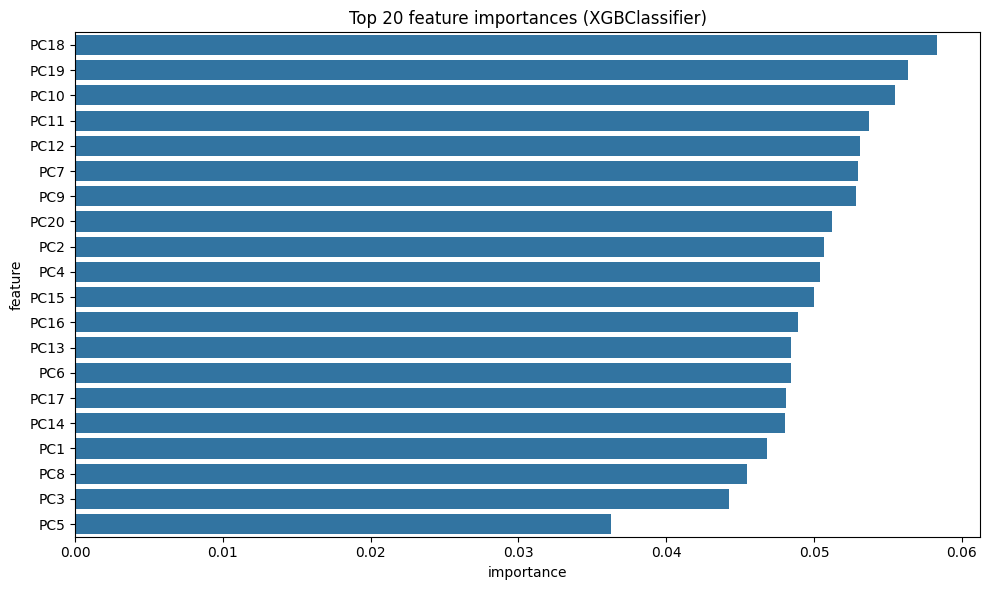

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

# Po wytrenowaniu modelu
importances = model_multi.feature_importances_

# Jeśli masz dane X jako DataFrame
feature_names = X_test_stage2.columns
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False)

# Wyświetlenie
plt.figure(figsize=(10, 6))
sns.barplot(x="importance", y="feature", data=importance_df.head(20))
plt.title("Top 20 feature importances (XGBClassifier)")
plt.tight_layout()
plt.show()
